In [3]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout,Input,Flatten,Dense,MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Data Augumentation


In [4]:
batchsize=8

In [5]:
train_datagen= ImageDataGenerator(rescale=1./255, rotation_range=0.2,shear_range=0.2,
    zoom_range=0.2,width_shift_range=0.2,
    height_shift_range=0.2, validation_split=0.2)

train_data= train_datagen.flow_from_directory(r'mrleyedataset\Train',
                                target_size=(80,80),batch_size=batchsize,class_mode='categorical',subset='training' )

validation_data= train_datagen.flow_from_directory(r'mrleyedataset\Train',
                                target_size=(80,80),batch_size=batchsize,class_mode='categorical', subset='validation')

Found 61497 images belonging to 2 classes.
Found 15373 images belonging to 2 classes.


In [6]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(r'mrleyedataset\Test',
                                target_size=(80,80),batch_size=batchsize,class_mode='categorical')

Found 8028 images belonging to 2 classes.


In [7]:
bmodel = InceptionV3(include_top=False, weights='imagenet', input_tensor=Input(shape=(80,80,3)))
hmodel = bmodel.output
hmodel = Flatten()(hmodel)
hmodel = Dense(64, activation='relu')(hmodel)
hmodel = Dropout(0.5)(hmodel)
hmodel = Dense(2,activation= 'softmax')(hmodel)

model = Model(inputs=bmodel.input, outputs= hmodel)
for layer in bmodel.layers:
    layer.trainable = False

In [8]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 80, 80, 3)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 39, 39, 32)           864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 39, 39, 32)           96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 39, 39, 32)           0         ['batch_normalization[0][0

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping, ReduceLROnPlateau

In [8]:
checkpoint = ModelCheckpoint(r'model\model.h5',
                            monitor='val_loss',save_best_only=True,verbose=3)

earlystop = EarlyStopping(monitor = 'val_loss', patience=7, verbose= 3, restore_best_weights=True)

learning_rate = ReduceLROnPlateau(monitor= 'val_loss', patience=3, verbose= 3, )

callbacks=[checkpoint,earlystop,learning_rate]

In [9]:
model.compile(optimizer='Adam', loss='categorical_crossentropy',metrics=['accuracy'])

model.fit_generator(train_data,steps_per_epoch=train_data.samples//batchsize,
                   validation_data=validation_data,
                   validation_steps=validation_data.samples//batchsize,
                   callbacks=callbacks,
                    epochs=5)

C:\Users\krish\AppData\Local\Temp\ipykernel_1664\3918530525.py:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(train_data,steps_per_epoch=train_data.samples//batchsize,


Epoch 1/5
7687/7687 [==============================] - ETA: 0s - loss: 0.2081 - accuracy: 0.9192
Epoch 1: val_loss improved from inf to 0.19458, saving model to model\model.h5


E:\ppp\new-env\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


7687/7687 [==============================] - 1228s 159ms/step - loss: 0.2081 - accuracy: 0.9192 - val_loss: 0.1946 - val_accuracy: 0.9168 - lr: 0.0010
Epoch 2/5
7687/7687 [==============================] - ETA: 0s - loss: 0.1772 - accuracy: 0.9316
Epoch 2: val_loss improved from 0.19458 to 0.18844, saving model to model\model.h5
7687/7687 [==============================] - 410s 53ms/step - loss: 0.1772 - accuracy: 0.9316 - val_loss: 0.1884 - val_accuracy: 0.9246 - lr: 0.0010
Epoch 3/5
7687/7687 [==============================] - ETA: 0s - loss: 0.1725 - accuracy: 0.9333
Epoch 3: val_loss improved from 0.18844 to 0.17845, saving model to model\model.h5
7687/7687 [==============================] - 452s 59ms/step - loss: 0.1725 - accuracy: 0.9333 - val_loss: 0.1784 - val_accuracy: 0.9286 - lr: 0.0010
Epoch 4/5
7687/7687 [==============================] - ETA: 0s - loss: 0.1649 - accuracy: 0.9388
Epoch 4: val_loss did not improve from 0.17845
7687/7687 [==============================] - 44

In [10]:
acc_tr, loss_tr = model.evaluate(train_data)
print(acc_tr)
print(loss_tr)

7688/7688 [==============================] - 387s 50ms/step - loss: 0.1380 - accuracy: 0.9475
0.13801148533821106
0.9475096464157104


1922/1922 [==============================] - 83s 43ms/step


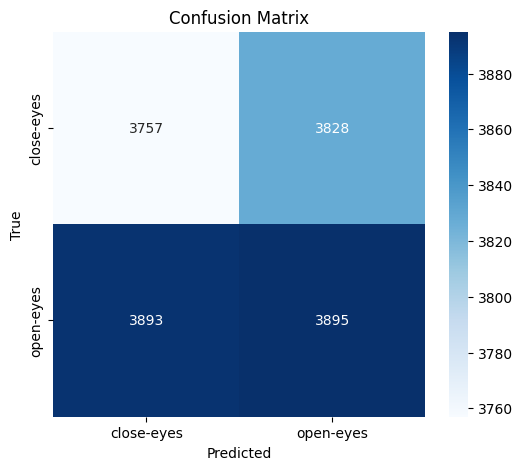

Classification Report:

              precision    recall  f1-score   support

  close-eyes       0.49      0.50      0.49      7585
   open-eyes       0.50      0.50      0.50      7788

    accuracy                           0.50     15373
   macro avg       0.50      0.50      0.50     15373
weighted avg       0.50      0.50      0.50     15373

Overall Accuracy: 0.4977558056332531


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ----------------------------
# Predictions on validation or test data
# ----------------------------
y_pred = model.predict(validation_data)              # predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)           # predicted class indices
y_true = validation_data.classes                     # true class indices
class_labels = list(validation_data.class_indices.keys())  # class names

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ----------------------------
# Classification Report
# ----------------------------
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# ----------------------------
# Overall Accuracy
# ----------------------------
acc = accuracy_score(y_true, y_pred_classes)
print("Overall Accuracy:", acc)


In [9]:
print(train_data.class_indices)
print(test_data.class_indices)


{'close-eyes': 0, 'open-eyes': 1}
{'close-eyes': 0, 'open-eyes': 1}


In [10]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout, Input, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

batchsize = 8

# ------------------- DATA GENERATORS -------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    r'mrleyedataset\Train',
    target_size=(80, 80),
    batch_size=batchsize,
    class_mode='categorical',
    subset='training'
)

validation_data = train_datagen.flow_from_directory(
    r'mrleyedataset\Train',
    target_size=(80, 80),
    batch_size=batchsize,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    r'mrleyedataset\Test',
    target_size=(80, 80),
    batch_size=batchsize,
    class_mode='categorical',
    shuffle=False
)

print("Train classes:", train_data.class_indices)
print("Test classes:", test_data.class_indices)

# ------------------- MODEL -------------------
bmodel = InceptionV3(
    include_top=False,
    weights='imagenet',
    input_tensor=Input(shape=(80, 80, 3))
)

x = bmodel.output
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=bmodel.input, outputs=output)

# Freeze base model
for layer in bmodel.layers:
    layer.trainable = False

# Compile
model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- CALLBACKS -------------------
checkpoint = ModelCheckpoint(
    r'model\best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    verbose=1,
    restore_best_weights=True
)

learning_rate = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

callbacks = [checkpoint, earlystop, learning_rate]

# ------------------- TRAINING -------------------
history = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // batchsize,
    validation_data=validation_data,
    validation_steps=validation_data.samples // batchsize,
    epochs=20,
    callbacks=callbacks
)

# ------------------- EVALUATION -------------------
print("Train accuracy on TRAIN DATA:")
loss_tr, acc_tr = model.evaluate(train_data)
print("Train loss:", loss_tr, "Train accuracy:", acc_tr)

print("Accuracy on TEST DATA:")
loss_te, acc_te = model.evaluate(test_data)
print("Test loss:", loss_te, "Test accuracy:", acc_te)


Found 61497 images belonging to 2 classes.
Found 15373 images belonging to 2 classes.
Found 8028 images belonging to 2 classes.
Train classes: {'close-eyes': 0, 'open-eyes': 1}
Test classes: {'close-eyes': 0, 'open-eyes': 1}
Epoch 1/20
7687/7687 [==============================] - ETA: 0s - loss: 0.2106 - accuracy: 0.9161
Epoch 1: val_loss improved from inf to 0.18557, saving model to model\best_model.h5


E:\ppp\new-env\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


7687/7687 [==============================] - 1432s 186ms/step - loss: 0.2106 - accuracy: 0.9161 - val_loss: 0.1856 - val_accuracy: 0.9217 - lr: 0.0010
Epoch 2/20
7686/7687 [============================>.] - ETA: 0s - loss: 0.1791 - accuracy: 0.9315
Epoch 2: val_loss improved from 0.18557 to 0.18551, saving model to model\best_model.h5
7687/7687 [==============================] - 408s 53ms/step - loss: 0.1791 - accuracy: 0.9315 - val_loss: 0.1855 - val_accuracy: 0.9225 - lr: 0.0010
Epoch 3/20
7686/7687 [============================>.] - ETA: 0s - loss: 0.1727 - accuracy: 0.9344
Epoch 3: val_loss did not improve from 0.18551
7687/7687 [==============================] - 474s 62ms/step - loss: 0.1727 - accuracy: 0.9344 - val_loss: 0.1887 - val_accuracy: 0.9185 - lr: 0.0010
Epoch 4/20
7687/7687 [==============================] - ETA: 0s - loss: 0.1670 - accuracy: 0.9364
Epoch 4: val_loss did not improve from 0.18551

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257

1004/1004 [==============================] - 50s 48ms/step


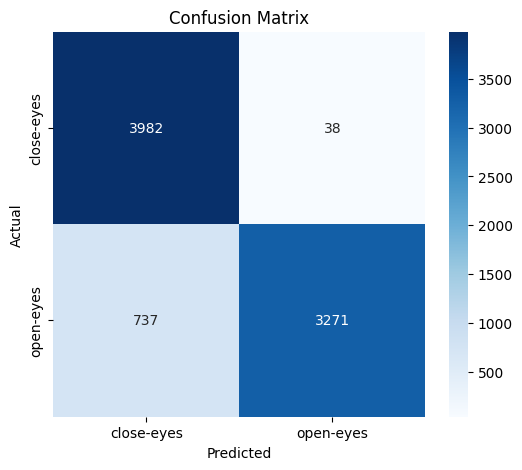

Classification Report:
              precision    recall  f1-score   support

  close-eyes       0.84      0.99      0.91      4020
   open-eyes       0.99      0.82      0.89      4008

    accuracy                           0.90      8028
   macro avg       0.92      0.90      0.90      8028
weighted avg       0.92      0.90      0.90      8028



In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------- PREDICTIONS -------------------
# Predict class probabilities
y_pred_probs = model.predict(test_data, verbose=1)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_data.classes

# Class labels (dictionary: class name → index)
class_labels = list(test_data.class_indices.keys())

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ------------------- CLASSIFICATION REPORT -------------------
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

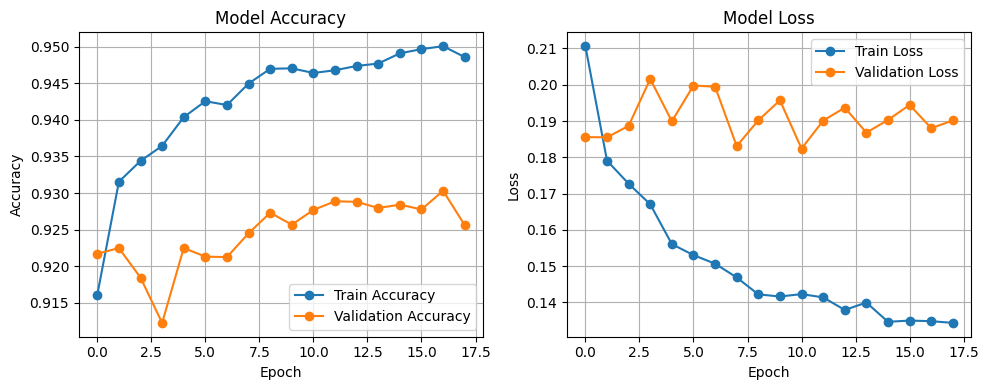

In [12]:
import matplotlib.pyplot as plt

# ------------------- ACCURACY CURVE -------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ------------------- LOSS CURVE -------------------
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()